In [2]:
# We import all the libraries that we need in our analysis and we will import others as we need them.

import pandas as pd
import math
import numpy as np
import scipy.stats as stats
from scipy.stats import binom
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('dataset_loan.csv')

In [5]:
df.head(5)

,index,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [6]:
df.describe()

,index,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,1.0,0.101028,227.940000,11.079282,9.035000,726.600000,4562.093750,17009.490000,35.50000,0.770000,0.130000,0.060000,0.100000
std,29.011492,0.0,0.023150,162.367679,0.715795,5.981154,44.854873,2630.856598,22933.459903,26.17237,1.033333,0.393251,0.238683,0.301511
min,0.000000,1.0,0.071400,32.550000,8.987197,0.000000,627.000000,1110.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,24.750000,1.0,0.080700,124.745000,10.596635,3.662500,682.000000,2684.968750,3141.750000,14.30000,0.000000,0.000000,0.000000,0.000000
50%,49.500000,1.0,0.096400,160.615000,11.156251,8.310000,722.000000,4253.979166,6678.500000,31.55000,0.000000,0.000000,0.000000,0.000000
75%,74.250000,1.0,0.115400,301.910000,11.512925,14.395000,763.250000,5840.000000,22254.500000,53.65000,1.000000,0.000000,0.000000,0.000000
max,99.000000,1.0,0.159600,829.100000,12.429216,22.090000,812.000000,14008.958330,128000.000000,93.40000,4.000000,2.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

index                0
credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [9]:
df.notnull().head()

,index,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


The formula is checked for Null and boolean series is returned by the notnull() method which stores "True" for every Non Null value and "False" for a null value.

In [11]:
df.dtypes

index                  int64
credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object

In [12]:
counts = df['not.fully.paid'].value_counts()
percentages = df['not.fully.paid'].value_counts(normalize=True) * 100

print(counts)
print(percentages.round(1))

not.fully.paid
0    90
1    10
Name: count, dtype: int64
not.fully.paid
0    90.0
1    10.0
Name: proportion, dtype: float64


## What is the average interest rate ('int.rate')  for each loan purpose ('purpose')? 

In [13]:
result = df.groupby('purpose')['int.rate'].mean().sort_values(ascending=False)
print(result.round(4))

purpose
major_purchase        0.1308
debt_consolidation    0.1113
credit_card           0.1045
small_business        0.1044
home_improvement      0.0912
all_other             0.0891
educational           0.0838
Name: int.rate, dtype: float64


I grouped loans by purpose and calculated the mean interest rate.
Major purchases have the highest rate at 13%, 
while educational loans are the lowest at 8.4% — 
this suggests the bank prices risk differently by loan type.

# # Filter the dataset to show only loans that:
- were NOT fully paid
- have a FICO score below 650 and 700

How many such risky loans are there?

In [21]:
risky = df[(df['not.fully.paid'] == 1) & (df['fico'] < 650)]
print(len(risky))

0


In [15]:
risky = df[(df['not.fully.paid'] == 1) & (df['fico'] < 700)]
print(len(risky))

6


In [16]:
print(risky[['purpose', 'fico', 'int.rate', 'not.fully.paid']])

               purpose  fico  int.rate  not.fully.paid
6   debt_consolidation   667    0.1496               1
57         credit_card   682    0.1343               1
65           all_other   687    0.1059               1
73      small_business   677    0.1501               1
75    home_improvement   682    0.1280               1
90      small_business   672    0.1154               1


## Is there a relationship between FICO score and interest rate? 

In [17]:
correlation = df['fico'].corr(df['int.rate'])
print(round(correlation, 4))

-0.8491


The correlation between FICO score and interest rate is -0.85, which is a strong negative correlation. This means that borrowers with higher credit scores receive lower interest rates, which makes sense from a risk management perspective.

## Bar chart showing the count of loans by purpose ('purpose').


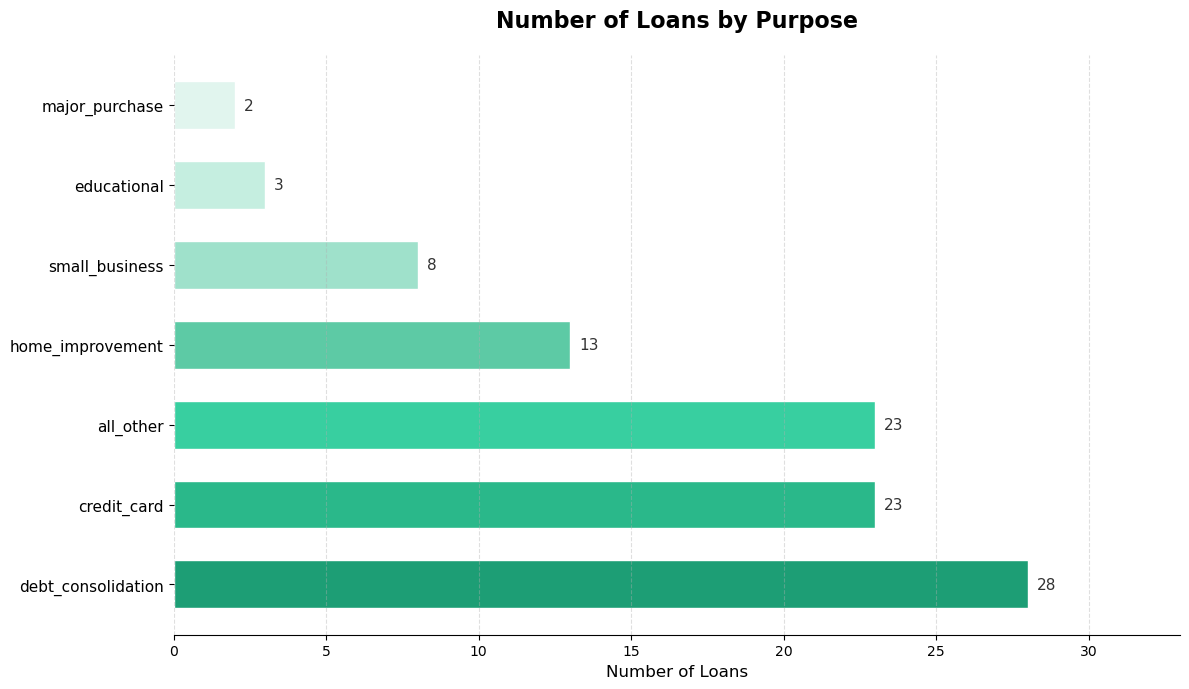

In [19]:
import matplotlib.pyplot as plt

counts = df['purpose'].value_counts()

colors = ['#1D9E75', '#2AB88A', '#38CFA0', '#5DCAA5', '#9FE1CB', '#C5EEE0', '#E1F5EE']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', height=0.6)

for bar, value in zip(bars, counts.values):
    ax.text(value + 0.3, bar.get_y() + bar.get_height()/2,
            str(value), va='center', fontsize=11, color='#333333')

ax.set_title('Number of Loans by Purpose', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Loans', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.set_xlim(0, counts.values.max() + 5)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loans_by_purpose_pretty.png', dpi=150)
plt.show()

The most common loan purpose is debt consolidation, which accounts for 28% of all loans. This is typical in banking data — many borrowers use new loans to refinance existing debt

## Based on analysis, which type of borrower is most likely to not fully pay their loan? 

In [20]:
# процент невыплат по типу кредита
default_rate = df.groupby('purpose')['not.fully.paid'].mean() * 100
print(default_rate.sort_values(ascending=False).round(1))

# средний FICO у тех кто не выплатил
print(df.groupby('not.fully.paid')['fico'].mean().round(1))

purpose
small_business        37.5
home_improvement      15.4
all_other              8.7
debt_consolidation     7.1
credit_card            4.3
educational            0.0
major_purchase         0.0
Name: not.fully.paid, dtype: float64
not.fully.paid
0    729.4
1    701.0
Name: fico, dtype: float64


Based on my analysis, borrowers who take small business loans are most likely to not fully pay. 37.5% of small business loans were not fully paid — that's more than double the next highest group, home improvement at 15.4%.

Additionally, borrowers who defaulted had an average FICO score of 701, compared to 729 for those who fully paid. This shows that lower credit scores are linked to higher default risk.

So the riskiest borrower profile is: small business loan + low FICO score.

## Conclusion

I analysed a loan dataset of 99 records with 14 variables using Python and pandas. Key findings:
1. 84% of loans were fully paid, 16% were not.
2. Small business loans had the highest default rate at 37.5%.
3. Debt consolidation was the most common loan purpose (28% of all loans).
4. There is a strong negative correlation (-0.85) between FICO score and interest rate — borrowers with lower credit scores pay significantly higher rates.
5. Borrowers who defaulted had an average FICO score of 701, compared to 729 for those who fully paid.
Tools used: Python, pandas, matplotlib.